In [1]:
# Import Libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set paths
biological_dir = '../dataset/biological'
plastic_dir = '../dataset/plastic'

valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', 'webp')

def get_paths(folder):
    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]

bio_paths = get_paths(biological_dir)
pla_paths = get_paths(plastic_dir)
total = len(bio_paths) + len(pla_paths)

print(f"Biological: {len(bio_paths)} images")
print(f"Plastic: {len(pla_paths)} images")
print(f"Total images: {total}")

Biological: 1042 images
Plastic: 1042 images
Total images: 2084


In [3]:
# Check and removed corruped images
def check_and_clean(img_paths, folder_name):
    corrupt = []
    for path in img_paths:
        try:
            img = Image.open(path)
            img.verify()  # Check if file is valid
        except Exception:
            corrupt.append(path)

    print(f'--- {folder_name} ---')
    print(f'  Total checked  : {len(img_paths)}')
    print(f'  Corrupt found  : {len(corrupt)}')

    if corrupt:
        print('  Removing corrupt files...')
        for path in corrupt:
            os.remove(path)
            print(f'Removed: {os.path.basename(path)}')
        print(f'Removed {len(corrupt)} corrupt files')
    else:
        print('No corrupt files found dataset is clean!')

    return corrupt

bc = check_and_clean(bio_paths, 'Biological')
print()
pc = check_and_clean(pla_paths, 'Plastic')

# Reload paths after cleaning
bio_paths = get_paths(biological_dir)
pla_paths = get_paths(plastic_dir)
total     = len(bio_paths) + len(pla_paths)
print(f'\nClean dataset: {len(bio_paths)} bio + {len(pla_paths)} plastic = {total} total')

--- Biological ---
  Total checked  : 1042
  Corrupt found  : 0
No corrupt files found dataset is clean!

--- Plastic ---
  Total checked  : 1042
  Corrupt found  : 0
No corrupt files found dataset is clean!

Clean dataset: 1042 bio + 1042 plastic = 2084 total


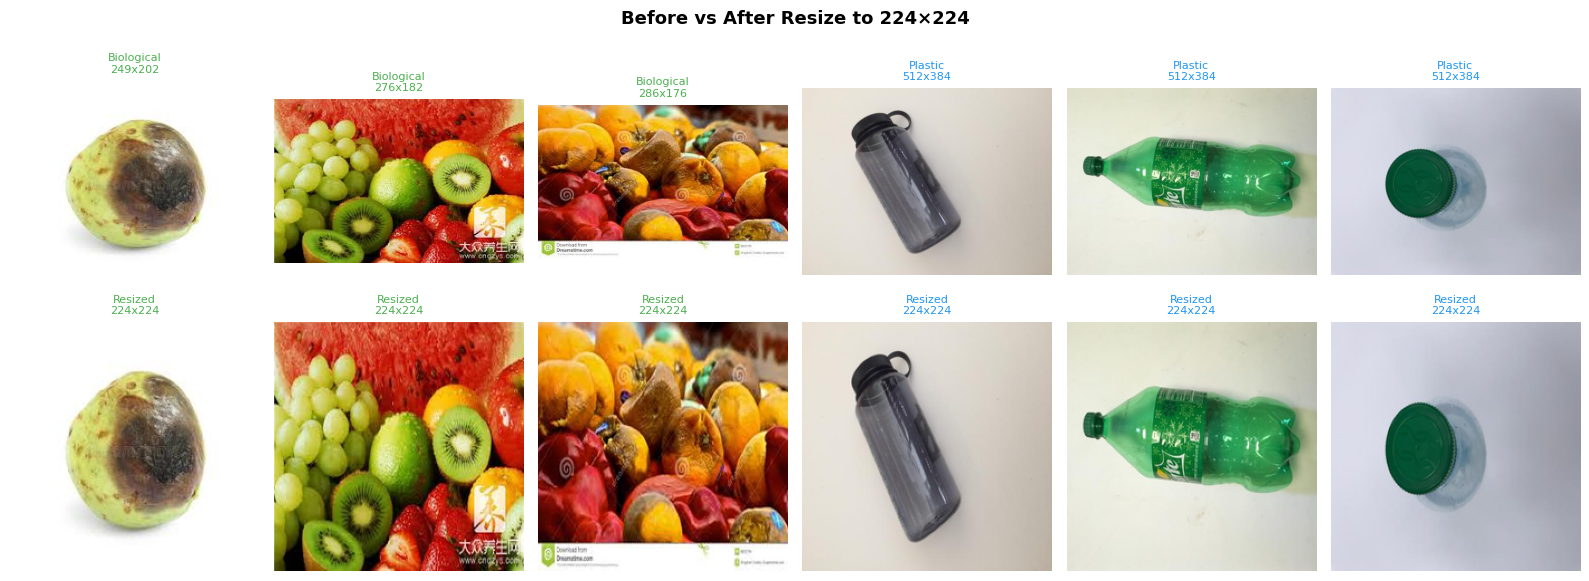

In [6]:
# Preview Resize to 224x224
random.seed(42)

TARGET_SIZE = (224, 224)

bio_sample = random.sample(bio_paths, 3)
pla_sample = random.sample(pla_paths, 3)
all_samples = bio_sample + pla_sample
labels      = ['Biological'] * 3 + ['Plastic'] * 3
label_colors= ['#4CAF50'] * 3 + ['#2196F3'] * 3

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Before vs After Resize to 224×224',
             fontsize=13, fontweight='bold')

for col, (path, label, color) in enumerate(zip(all_samples, labels, label_colors)):
    original = Image.open(path).convert('RGB')
    resized  = original.resize(TARGET_SIZE, Image.LANCZOS)

    # Original
    axes[0][col].imshow(original)
    axes[0][col].axis('off')
    axes[0][col].set_title(
        f'{label}\n{original.size[0]}x{original.size[1]}',
        color=color, fontsize=8
    )

    # Resized
    axes[1][col].imshow(resized)
    axes[1][col].axis('off')
    axes[1][col].set_title(
        f'Resized\n224x224',
        color=color, fontsize=8
    )

axes[0][0].set_ylabel('Original', fontsize=10, fontweight='bold')
axes[1][0].set_ylabel('224×224', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

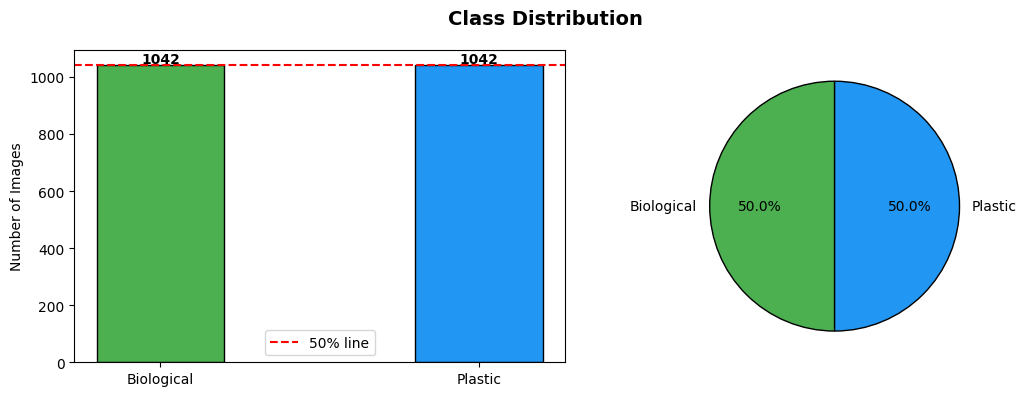

In [5]:
# Class Distribution
counts = {
    'Biological': len(bio_paths),
    'Plastic': len(pla_paths)
}
colors = ['#4CAF50', '#2196F3']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Class Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(counts.keys(), counts.values(), 
                   color=colors, edgecolor='black', width=0.4)
axes[0].axhline(total / 2, color='red', linestyle='--', label='50% line')
axes[0].set_ylabel('Number of Images')
axes[0].legend()
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        str(int(bar.get_height())),
        ha='center', fontweight='bold'
    )

# Pie chart
axes[1].pie(
    counts.values(), labels=counts.keys(),
    colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor': 'black'}
)

plt.tight_layout()
plt.show()

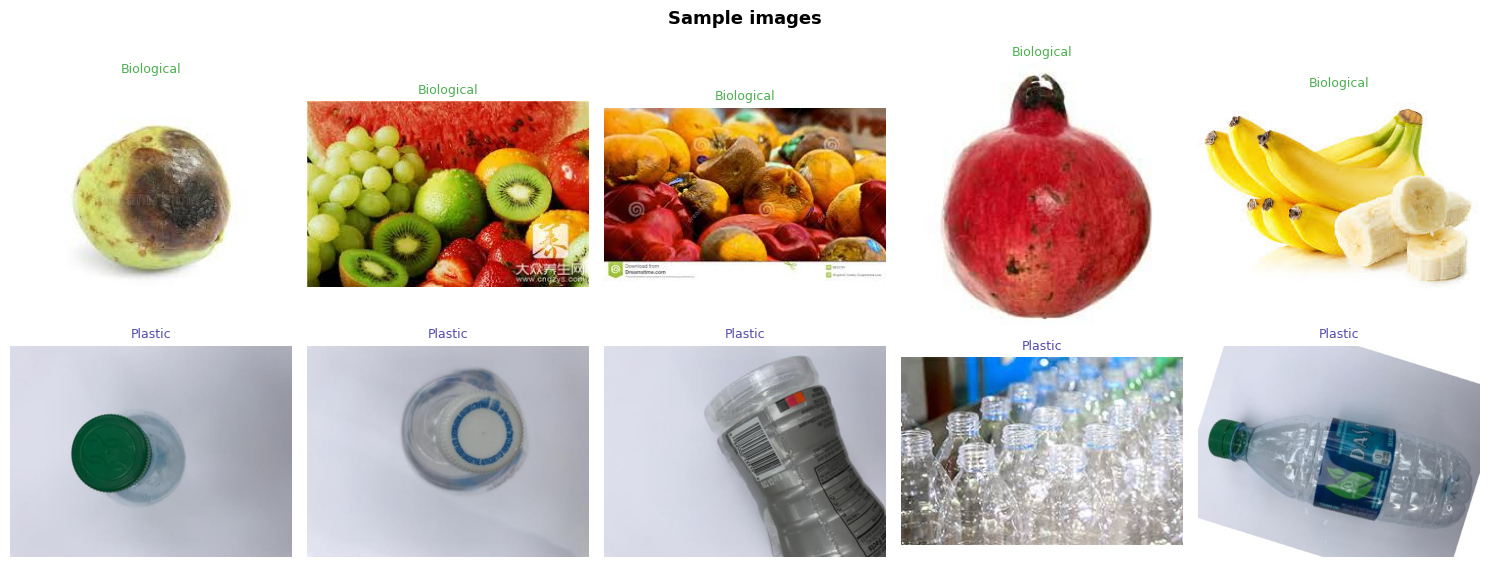

In [9]:
# Sample Images
random.seed(42)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample images', fontsize=13, fontweight='bold')

for col, path in enumerate(random.sample(bio_paths, 5)):
    axes[0][col].imshow(Image.open(path).convert('RGB'))
    axes[0][col].axis('off')
    axes[0][col].set_title('Biological', color='#4CAF50', fontsize=9)

for col, path in enumerate(random.sample(pla_paths, 5)):
    axes[1][col].imshow(Image.open(path).convert('RGB'))
    axes[1][col].axis('off')
    axes[1][col].set_title('Plastic', color="#534CAF", fontsize=9)

plt.tight_layout()
plt.show()

In [10]:
# Image size & Corrupt Check
def get_image_stats(img_paths):
    widths, heights, corrupt = [], [], []
    for path in img_paths:
        try:
            w, h = Image.open(path).size
            widths.append(w)
            heights.append(h)
        except:
            corrupt.append(os.path.basename(path))
    return widths, heights, corrupt

bw, bh, bc = get_image_stats(bio_paths)
pw, ph, pc = get_image_stats(pla_paths)

print('--- Biological ---')
print(f'  Width  : min={min(bw)}  max={max(bw)}  avg={int(np.mean(bw))}')
print(f'  Height : min={min(bh)}  max={max(bh)}  avg={int(np.mean(bh))}')
print(f'  Unique sizes : {len(set(zip(bw, bh)))}')
print(f'  Corrupt files: {len(bc)}')

print('\n--- Plastic ---')
print(f'  Width  : min={min(pw)}  max={max(pw)}  avg={int(np.mean(pw))}')
print(f'  Height : min={min(ph)}  max={max(ph)}  avg={int(np.mean(ph))}')
print(f'  Unique sizes : {len(set(zip(pw, ph)))}')
print(f'  Corrupt files: {len(pc)}')

--- Biological ---
  Width  : min=156  max=4032  avg=335
  Height : min=112  max=4608  avg=268
  Unique sizes : 202
  Corrupt files: 0

--- Plastic ---
  Width  : min=140  max=4032  avg=505
  Height : min=146  max=4608  avg=424
  Unique sizes : 156
  Corrupt files: 0


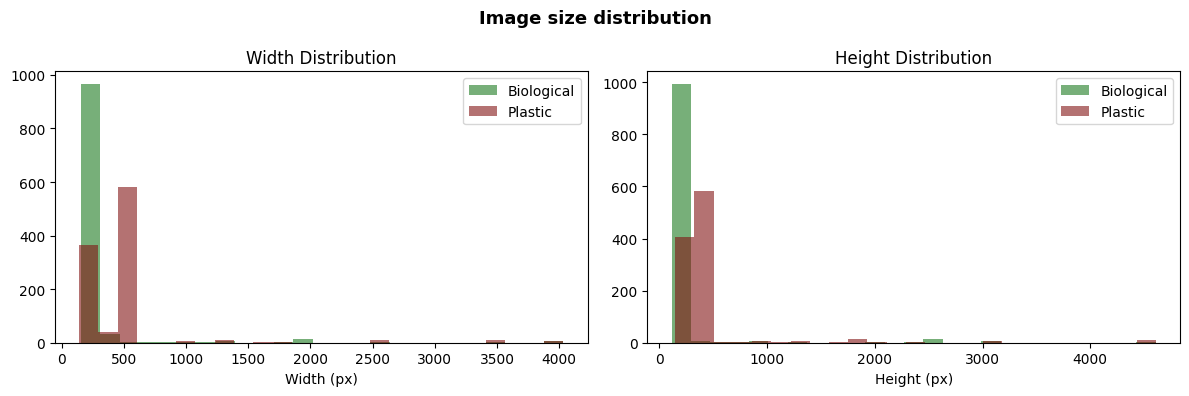

In [11]:
# Size distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Image size distribution', fontsize=13, fontweight='bold')

axes[0].hist(bw, bins=25, alpha=0.6, color="#1D7B20", label='Biological')
axes[0].hist(pw, bins=25, alpha=0.6, color="#821414", label='Plastic')
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].legend()

axes[1].hist(bh, bins=25, alpha=0.6, color="#1D7B20", label='Biological')
axes[1].hist(ph, bins=25, alpha=0.6, color="#821414", label='Plastic')
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Height (px)')
axes[1].legend()

plt.tight_layout()
plt.show()

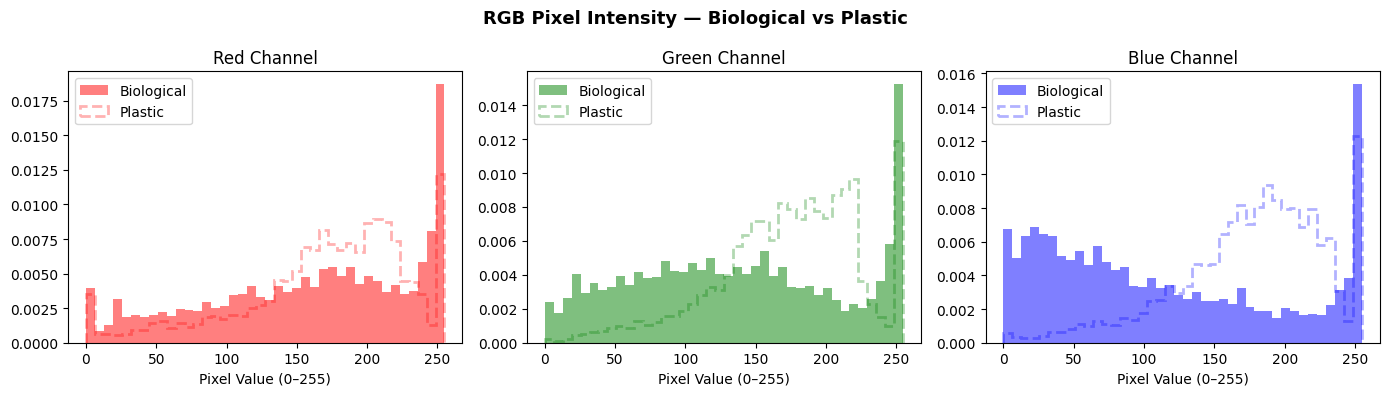

In [12]:
# RGB pixel intensity
def get_rgb(paths, n=50):
    r, g, b = [], [], []
    for path in random.sample(paths, min(n, len(paths))):
        try:
            arr = np.array(
                Image.open(path).convert('RGB').resize((64, 64))
            )
            r.extend(arr[:, :, 0].flatten())
            g.extend(arr[:, :, 1].flatten())
            b.extend(arr[:, :, 2].flatten())
        except:
            pass
    return r, g, b

br, bg, bb = get_rgb(bio_paths)
pr, pg, pb = get_rgb(pla_paths)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('RGB Pixel Intensity — Biological vs Plastic',
             fontsize=13, fontweight='bold')

for ax, bvals, pvals, ch, col in zip(
    axes,
    [br, bg, bb], [pr, pg, pb],
    ['Red', 'Green', 'Blue'],
    ['red', 'green', 'blue']
):
    ax.hist(bvals, bins=40, alpha=0.5, color=col,
            label='Biological', density=True)
    ax.hist(pvals, bins=40, alpha=0.3, color=col,
            label='Plastic', density=True,
            linestyle='--', histtype='step', linewidth=2)
    ax.set_title(f'{ch} Channel')
    ax.set_xlabel('Pixel Value (0–255)')
    ax.legend()

plt.tight_layout()
plt.show()

In [13]:
need = len(bio_paths) - len(pla_paths)
target   = max(len(bio_paths), len(pla_paths))

print('=' * 52)
print('        EDA SUMMARY — SMART BIN PROJECT')
print('=' * 52)
print(f'  Biological images  : {len(bio_paths)} ({len(bio_paths)/total*100:.1f}%)')
print(f'  Plastic images     : {len(pla_paths)} ({len(pla_paths)/total*100:.1f}%)')
print(f'  Total images       : {total}')
print(f'  Class gap          : {need} images')
print(f'  Unique bio sizes   : {len(set(zip(bw, bh)))}')
print(f'  Unique pla sizes   : {len(set(zip(pw, ph)))}')
print('-' * 52)

        EDA SUMMARY — SMART BIN PROJECT
  Biological images  : 1042 (50.0%)
  Plastic images     : 1042 (50.0%)
  Total images       : 2084
  Class gap          : 0 images
  Unique bio sizes   : 202
  Unique pla sizes   : 156
----------------------------------------------------
